# Fig07-Fig09 Showcase Notebook

这个 notebook 只负责展示和串行运行，不替代正式的 `.py` 产线。

## 为什么 Fig08 有两个脚本

- `02_fig08_solar_cycle_summary.py`：先从正式子集扫描结果中整理出 `Fig08_solar_cycle_subset_summary.csv`。
- `03_fig08_solar_cycle_viz.py`：再读取这个汇总 CSV，生成 `Fig08_solar_cycle_stability.eps/png`。

拆成两步的原因是：`Fig08` 既有图，也有正文直接依赖的汇总表；把“汇总表生成”和“画图”分开，更容易审计和单独重跑。

这个 notebook 会按顺序运行：Fig07 -> Fig08 summary -> Fig08 figure -> Fig09。

In [11]:
from pathlib import Path
import os
import shlex
import subprocess

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'notebooks' / '05_multidimensional').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / '05_multidimensional'
RESULT_DIR = PROJECT_ROOT / 'results' / '05_multidimensional'
FIG_DIR = PROJECT_ROOT / 'submission' / 'figures_2026'
CONDA_ENV = 'py313_tian_env'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('NOTEBOOK_DIR  =', NOTEBOOK_DIR)
print('RESULT_DIR    =', RESULT_DIR)
print('FIG_DIR       =', FIG_DIR)


PROJECT_ROOT = /data/solar-ceos/202603二修版
NOTEBOOK_DIR  = /data/solar-ceos/202603二修版/notebooks/05_multidimensional
RESULT_DIR    = /data/solar-ceos/202603二修版/results/05_multidimensional
FIG_DIR       = /data/solar-ceos/202603二修版/submission/figures_2026


In [12]:
SCRIPTS = [
    '01_fig07_subset_scan_viz.py',
    '02_fig08_solar_cycle_summary.py',
    '03_fig08_solar_cycle_viz.py',
    '04_fig09_robustness_viz.py',
]

def run_script(script_name: str) -> None:
    script_path = NOTEBOOK_DIR / script_name
    cmd = ['conda', 'run', '-n', CONDA_ENV, 'python', str(script_path)]
    print('\n' + '=' * 80)
    print('RUN:', ' '.join(shlex.quote(x) for x in cmd))
    print('=' * 80)
    proc = subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
        check=False,
    )
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0:
        if proc.stderr:
            print(proc.stderr)
        raise RuntimeError(f'{script_name} failed with exit code {proc.returncode}')
    if proc.stderr:
        print(proc.stderr)


In [13]:
for script_name in SCRIPTS:
    run_script(script_name)

print('\nAll scripts finished.')


RUN: conda run -n py313_tian_env python '/data/solar-ceos/202603二修版/notebooks/05_multidimensional/01_fig07_subset_scan_viz.py'
Formal subset-scan analysis completed.
  Reference window: w=2 deg
  Best single subset: Ven
  Best multi-planet subset: Ven+Mar
  Single-planet ranking: Ven > Mar > Jup > Mer > Sat > Ura > Nep
  Outputs written to results/05_multidimensional/



RUN: conda run -n py313_tian_env python '/data/solar-ceos/202603二修版/notebooks/05_multidimensional/02_fig08_solar_cycle_summary.py'
Solar-cycle summary completed.
  SC : /data/solar-ceos/202603二修版/results/05_multidimensional/Fig08_solar_cycle_subset_summary.csv



RUN: conda run -n py313_tian_env python '/data/solar-ceos/202603二修版/notebooks/05_multidimensional/03_fig08_solar_cycle_viz.py'
Solar cycle stability figure generated.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists

In [14]:
expected_outputs = [
    RESULT_DIR / 'Fig07_subset_scan_combined.eps',
    RESULT_DIR / 'Fig07_subset_scan_combined.png',
    RESULT_DIR / 'Fig07_subset_scan_summary.csv',
    RESULT_DIR / 'Fig08_solar_cycle_subset_summary.csv',
    RESULT_DIR / 'Fig08_solar_cycle_stability.eps',
    RESULT_DIR / 'Fig08_solar_cycle_stability.png',
    RESULT_DIR / 'Fig09_robustness_combined.eps',
    RESULT_DIR / 'Fig09_robustness_combined.png',
    FIG_DIR / 'Fig07_subset_scan_combined.eps',
    FIG_DIR / 'Fig08_solar_cycle_stability.eps',
    FIG_DIR / 'Fig09_robustness_combined.eps',
]

for path in expected_outputs:
    print(f'{path}:', 'OK' if path.exists() else 'MISSING')


/data/solar-ceos/202603二修版/results/05_multidimensional/Fig07_subset_scan_combined.eps: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig07_subset_scan_combined.png: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig07_subset_scan_summary.csv: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig08_solar_cycle_subset_summary.csv: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig08_solar_cycle_stability.eps: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig08_solar_cycle_stability.png: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig09_robustness_combined.eps: OK
/data/solar-ceos/202603二修版/results/05_multidimensional/Fig09_robustness_combined.png: OK
/data/solar-ceos/202603二修版/submission/figures_2026/Fig07_subset_scan_combined.eps: OK
/data/solar-ceos/202603二修版/submission/figures_2026/Fig08_solar_cycle_stability.eps: OK
/data/solar-ceos/202603二修版/submission/figures_2026/Fig09_robustness_combined.eps: OK


## Fig07

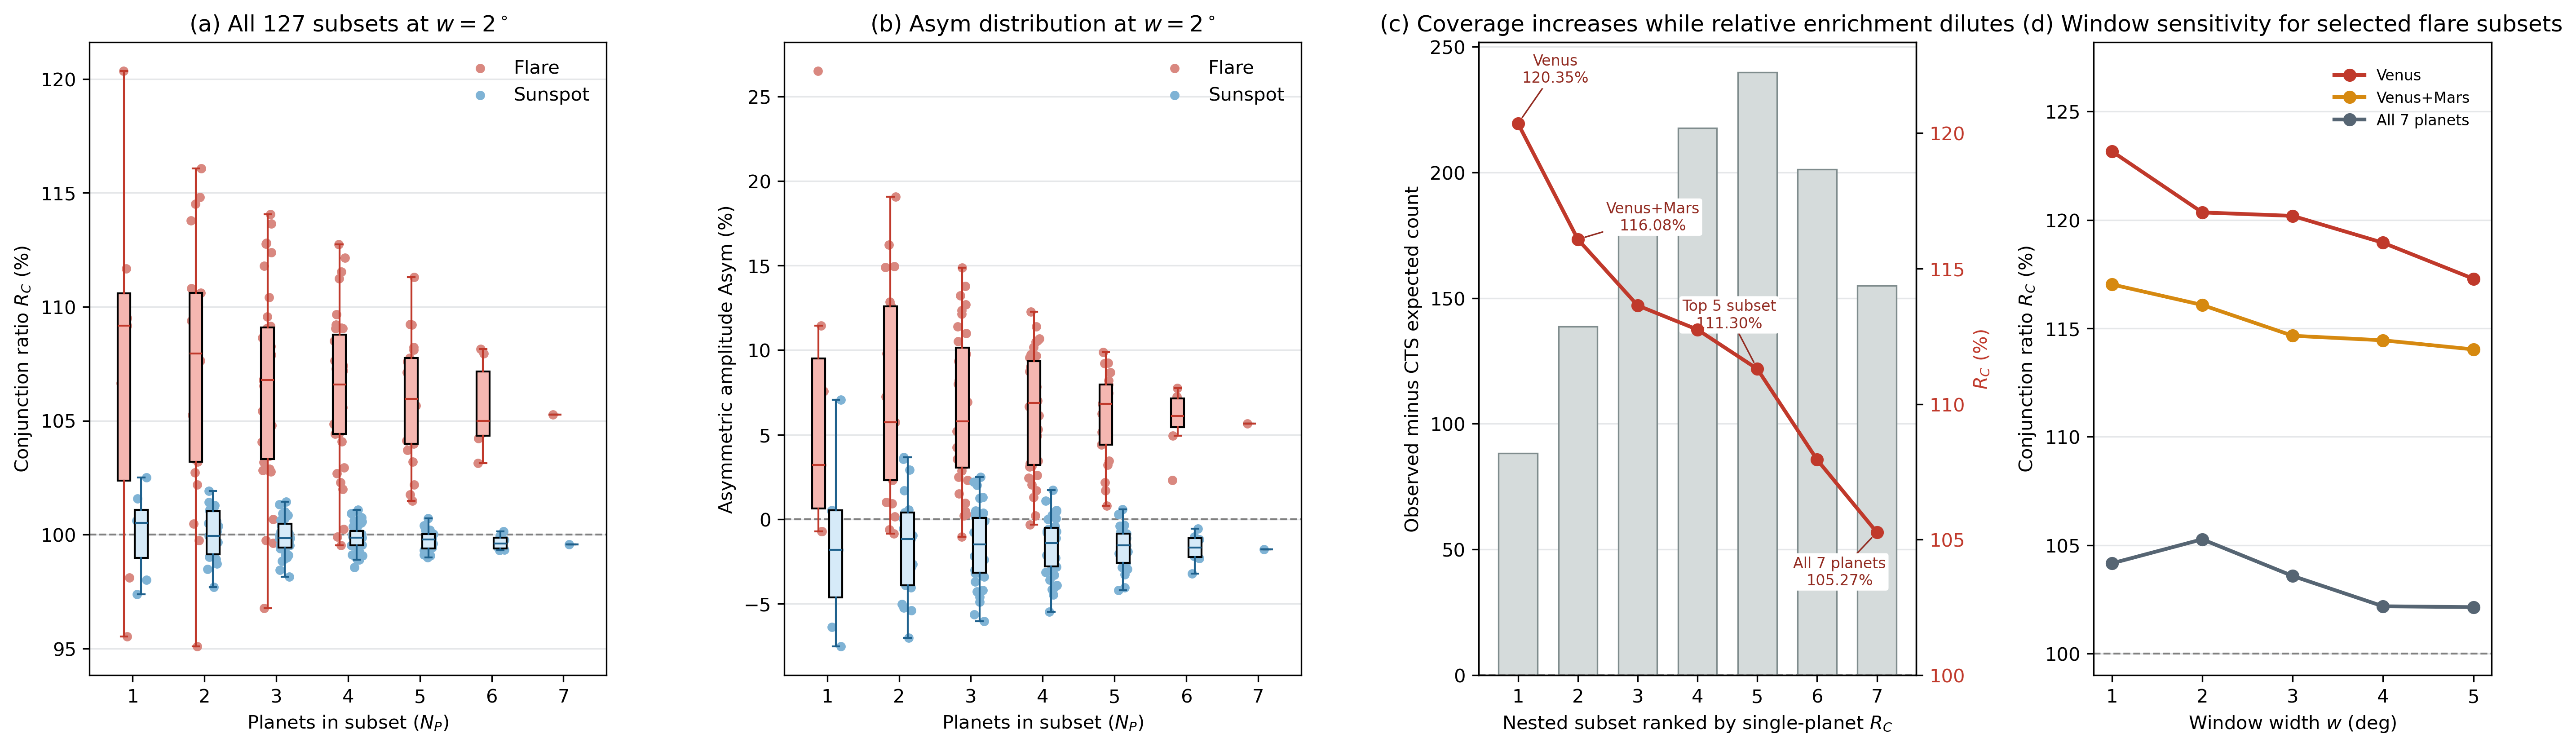

## Fig08

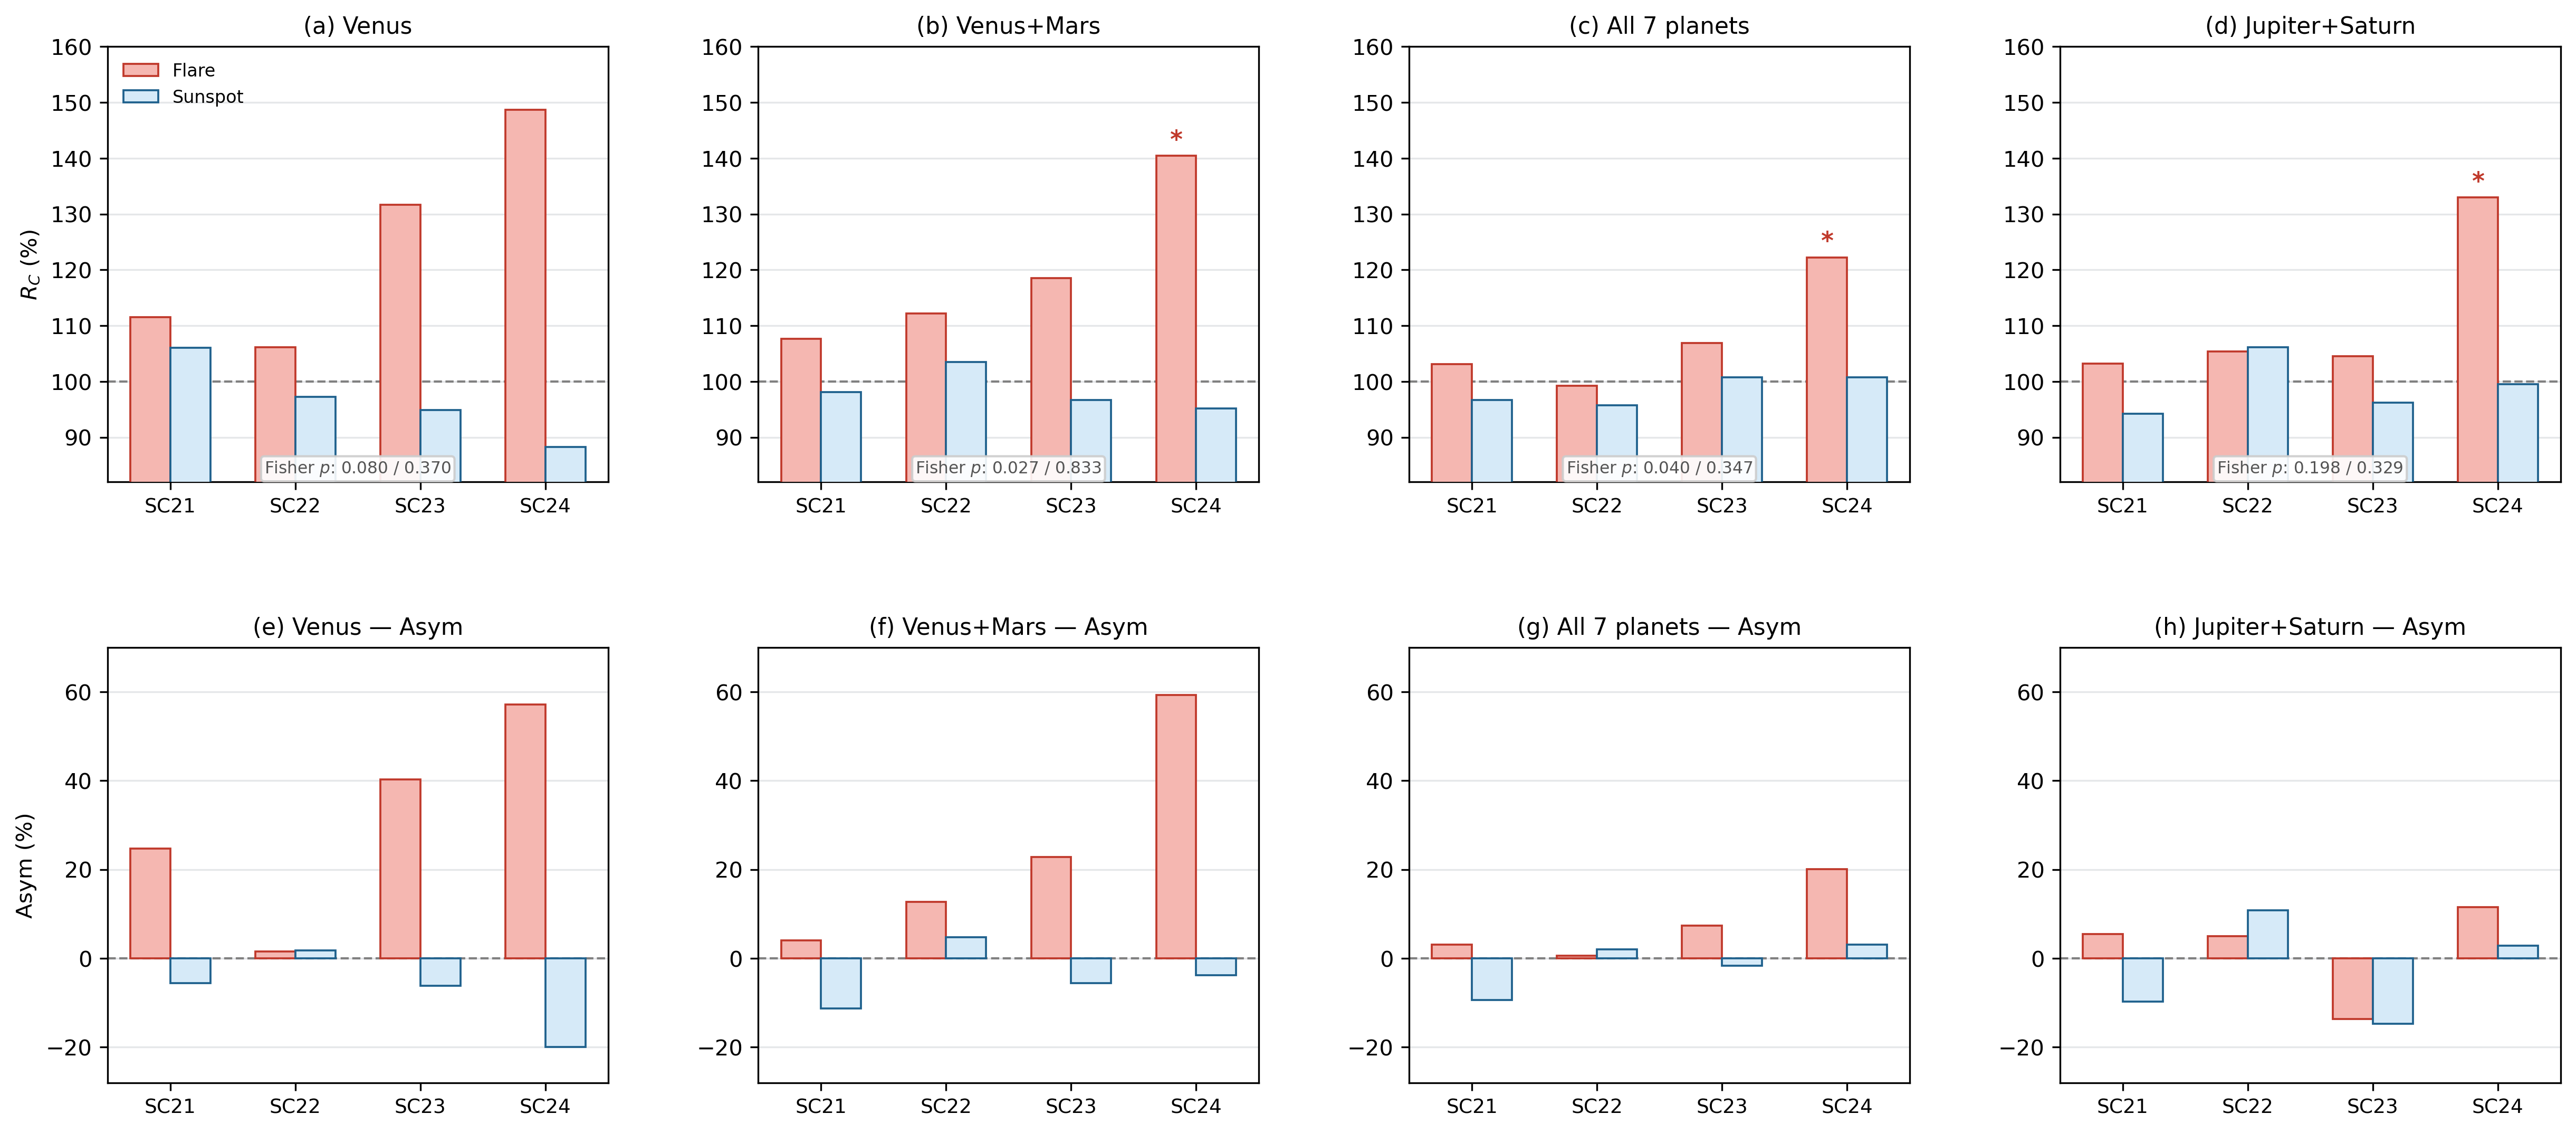

## Fig09

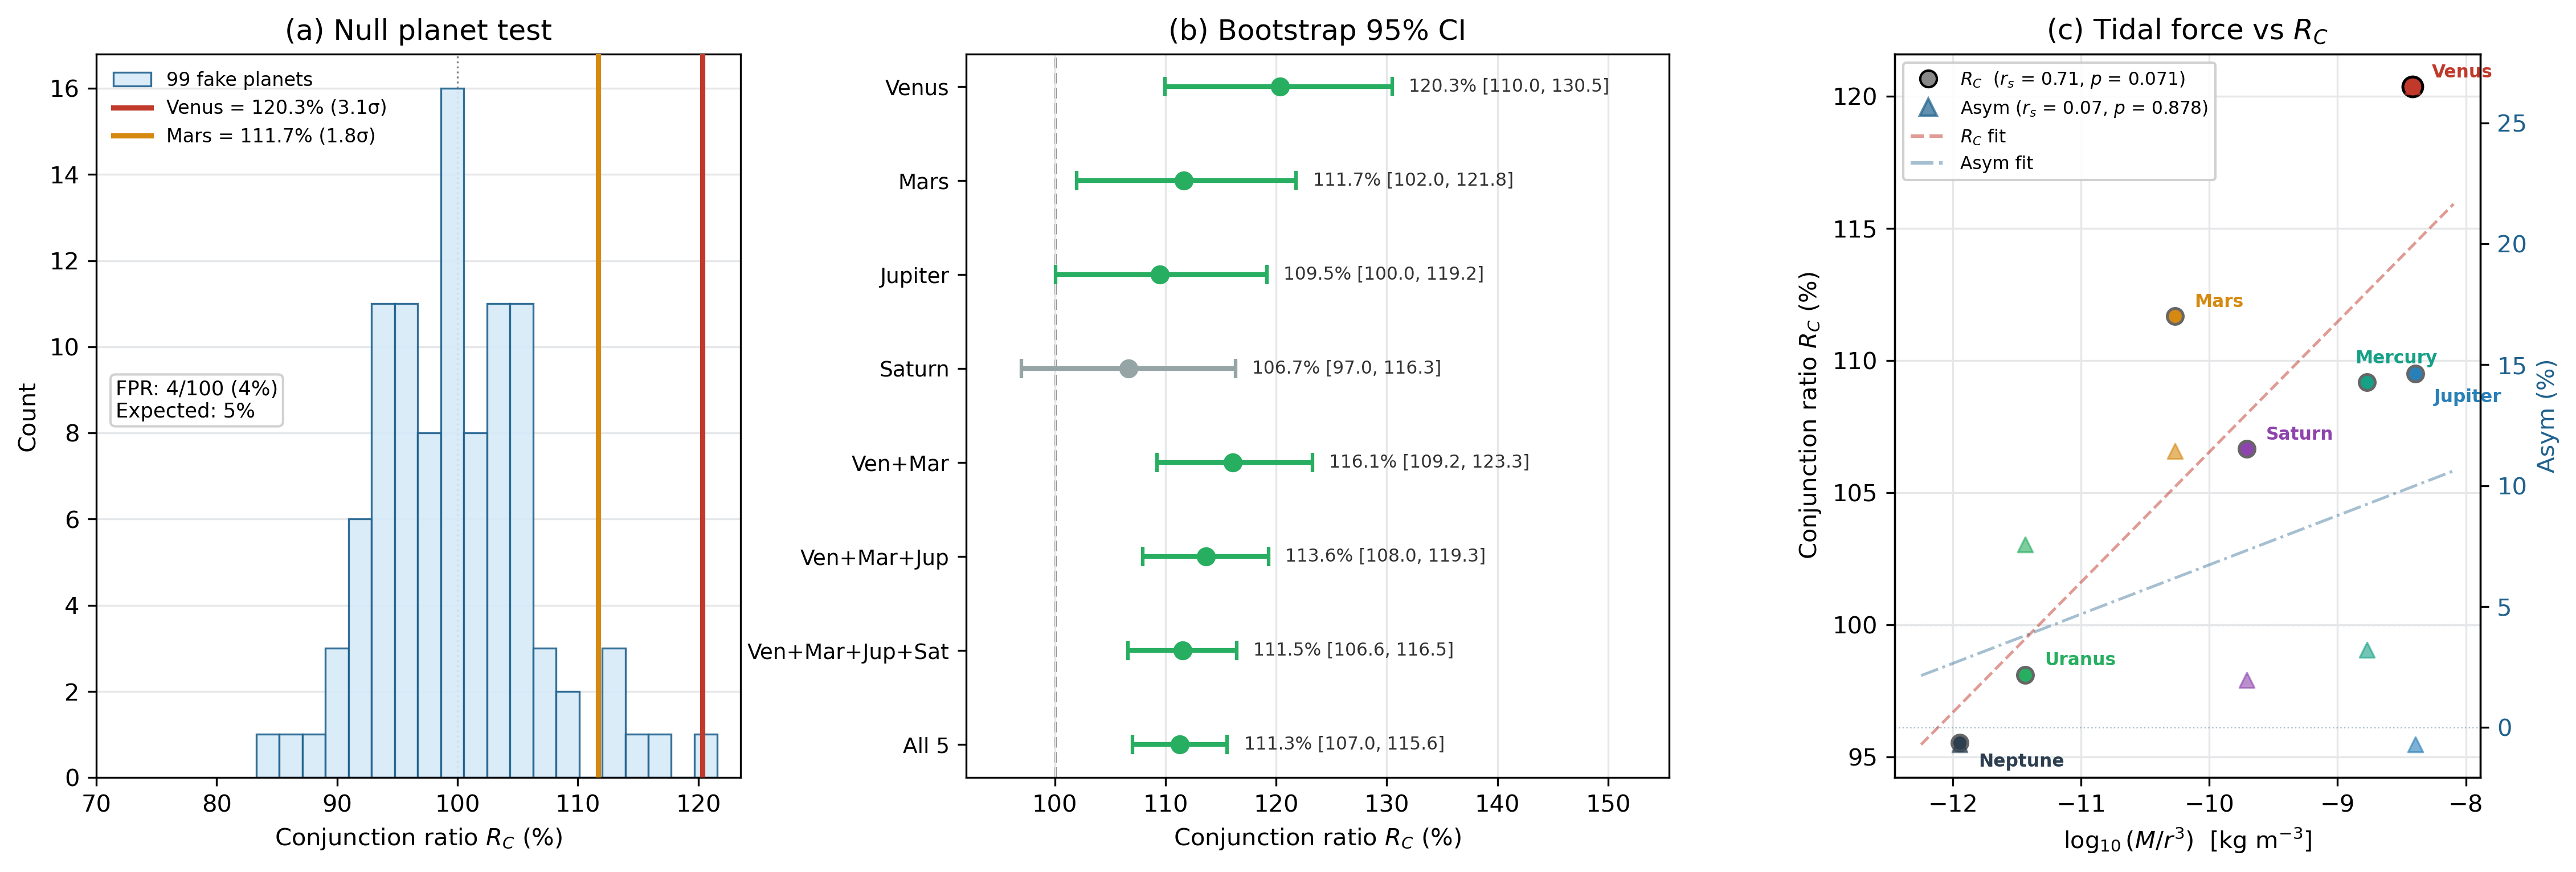

In [15]:
from IPython.display import Image, display, Markdown

pngs = [
    ('Fig07', RESULT_DIR / 'Fig07_subset_scan_combined.png'),
    ('Fig08', RESULT_DIR / 'Fig08_solar_cycle_stability.png'),
    ('Fig09', RESULT_DIR / 'Fig09_robustness_combined.png'),
]

for title, path in pngs:
    display(Markdown(f'## {title}'))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Missing:', path)
